In [48]:
import os
import numpy as np
from sklearn.datasets import make_classification

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from tqdm import tqdm

In [ ]:
# Environment provided 
class Contextual_Bandit_generator:
    #@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@
    def __init__(self, config):
        """
        Constructor for environment
        congfig dict contains number of samples for generating a 5 label classifier
        """
        self.state = {'X':[],'article':[],'reward':[]}
        self.population = [[],[]]
        self.population[0], self.population[1] = make_classification(
            n_samples=config['n_samples'],
            n_features=5,
            n_informative=5,
            n_classes=5,
            n_redundant=0,
            n_repeated=0,
            flip_y=0.2,
            shift = [10,4,0,0,0],
            scale = [7,1,1,1,1],
            random_state=8
        )
        self.population[0] = self.feature_engineer(self.population[0])
        self.current_context = {'X':[],'best_article':[]}
        
    #@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@
    def feature_engineer(self, Data):
        """
        Applies feature engineering to specific actions, makes them consistent for testing
        """
        Data[:,0] = (Data[:,0]>0)*1
        Data[:,1] = (Data[:,1]>0)*1
        Data[:,3][(Data[:,3]<0)] = 0
        Data[:,3][(Data[:,3]>5)] = 5
        Data[:,3] = np.round(Data[:,3])
        Data[:,4] = np.round(Data[:,4])
        return Data

    #@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@
    def step(self):
        """
        Selects a random article to best article, saves the current state the X list
        """
        sample = np.random.choice(len(self.population[1]))
        x = self.population[0][sample]
        ba = self.population[1][sample]
        if len(self.state['X']) == 0:
            self.state['X'] = x
        else:
            self.state['X'] = np.vstack((self.state['X'],x))
        self.current_context['X'] = x
        self.current_context['best_article'] = ba

    #@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@
    def reward(self,a):   
        """
        Checks if the provided article is the current best article
        if it is save 1, if not save 0
        save article and reward to environment storage
        """     
        if self.current_context['best_article'] == a:
            response = np.random.binomial(n = 1, p = 0.9,size = 1)[0]
        else:
            response = np.random.binomial(n = 1, p = 0.05,size = 1)[0]
        if len(self.state['X']) == 0:      
            self.state['article'] = np.array(a)
            self.state['reward'] = np.array(response)
        else:
            self.state['article'] = np.append(self.state['article'],a)
            self.state['reward'] = np.append(self.state['reward'],response)

In [ ]:
class Agent:
    def __init__(self, b, T, eps, env_config):
        self.b = b # num turns while greedy before refit
        self.T = T # number of training turns
        self.eps = eps # float {0,1} that dictates greed prob
        self.env = Contextual_Bandit_generator(env_config)

    def score(self, a, r):
        qt = self.acts[a][0] # Qt-1
        nt = self.acts[a][1]+1 # Nt(a)
        Qt = qt-((r-qt)/nt)
        # update dict
        self.acts[a][0] = Qt
        self.acts[a][1] = nt

    def greed(self): # finds the 'best' action to take
            actions = self.env.state['article']
            rewards = self.env.state['reward']
            df = pd.DataFrame(data={
                 'action':actions,
                 'reward':rewards
            })
            prob_dict = {'a':[], 'p':[]}
            for a in df['action'].unique():
                 r_sum = df.loc[df['action'] == a]['reward'].sum()
                 prob = r_sum/df.shape[0]
                 prob_dict['a'].append(a)
                 prob_dict['p'].append(prob)
            dt = pd.DataFrame(data=prob_dict)          
            if not dt['p'].ge(self.eps).empty:
                 choice = dt['p'].idxmax()
            else:
                 choice = dt.loc[dt['p']>=self.eps].idxmax()
            return choice

    def save_df(self):
        data = {
            'steps':[i for i in range(1,len(self.env.state['article'])+1)],
            'articles':self.env.state['article'],
            'rewards':self.env.state['reward']
        }
        print(len(data['steps']))
        df = pd.DataFrame(data=data)
        fname = f"MAB_T{self.T}_b{self.b}_eps{self.eps}.csv"
        df.to_csv(os.path.join('results', fname), index=False)
                          
    
    def run(self):
        for idx in tqdm(range(50000)): 
            if idx <=self.T: # training 
                self.env.step()
                action = np.random.choice(5) 
                self.env.reward(action)
                greedy_action = self.greed()
            else:
                self.env.step()
                self.env.reward(greedy_action)
            if (idx % self.b == 0) and idx >self.T: # every b steps retrain
                 greedy_action = self.greed()
        return np.mean(self.env.state['reward'])
        
        


In [108]:
# T = 100, b=100 eps = 0.1
env_config = {'n_samples':100000}
T = 100
b = 100
eps = 0.1
agent = Agent(b, T, eps, env_config)
agent.run()

100%|██████████| 50000/50000 [00:02<00:00, 17278.06it/s]


np.float64(0.22014)

In [109]:
training_times = [100, 250, 500, 750, 1000]
greed_time = [100, 1000]
epsilons = [0, 0.05, 0.1, 0.2,0.3,0.4,0.5]

data = {
    'traing_time':[],
    'greed_time':[],
    'epsilon':[],
    'avg_reward':[]
}

for tt in training_times:
    for gt in greed_time:
        for ee in epsilons:
            print(f"T:{tt} b:{gt} Epsilon:{ee}")
            agent = Agent(gt, tt, ee, env_config)
            mean = agent.run()
            # agent.save_df()
            data['traing_time'].append(tt)
            data['greed_time'].append(gt)
            data['epsilon'].append(ee)
            data['avg_reward'].append(mean)

dt = pd.DataFrame(data=data)

T:100 b:100 Epsilon:0


100%|██████████| 50000/50000 [00:02<00:00, 17882.89it/s]


T:100 b:100 Epsilon:0.05


100%|██████████| 50000/50000 [00:02<00:00, 18630.25it/s]


T:100 b:100 Epsilon:0.1


...

100%|██████████| 50000/50000 [00:02<00:00, 16731.94it/s]


T:1000 b:1000 Epsilon:0.4


100%|██████████| 50000/50000 [00:03<00:00, 16517.85it/s]


T:1000 b:1000 Epsilon:0.5


100%|██████████| 50000/50000 [00:03<00:00, 16620.95it/s]


In [110]:
dt.head()

,traing_time,greed_time,epsilon,avg_reward
0,100,100,0.00,0.22312
1,100,100,0.05,0.21706
2,100,100,0.10,0.22350
3,100,100,0.20,0.21882
4,100,100,0.30,0.22058


In [111]:
dt['epsilon'] = dt['epsilon'].astype('category')

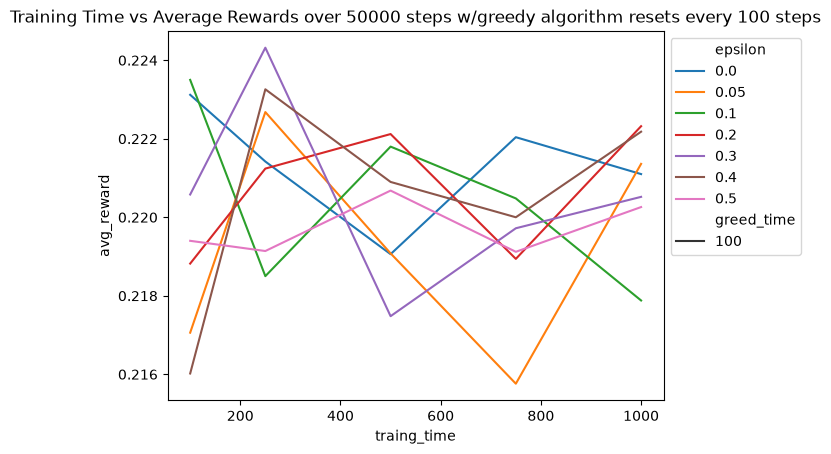

In [117]:
ax = sns.lineplot(data=dt.loc[dt['greed_time']==100], x='traing_time', y='avg_reward', hue='epsilon', style='greed_time')
sns.move_legend(ax, 'upper left', bbox_to_anchor=(1,1))
ax.set_title('Training Time vs Average Rewards over 50000 steps w/greedy algorithm resets every 100 steps')
plt.savefig(fname=os.path.join('plots', f"greed_100.png"), format='png', bbox_inches='tight')

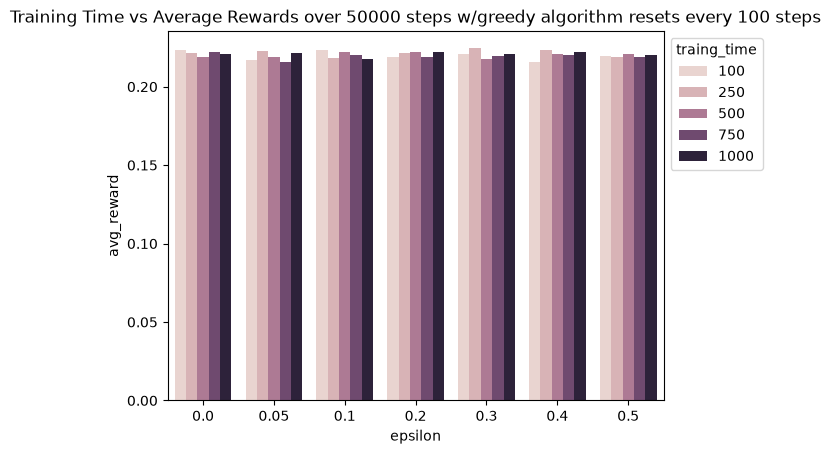

In [138]:
ax = sns.barplot(data=dt[dt['greed_time']==100], hue='traing_time', y='avg_reward', x='epsilon', )
sns.move_legend(ax, 'upper left', bbox_to_anchor=(1,1))
ax.set_title('Training Time vs Average Rewards over 50000 steps w/greedy algorithm resets every 100 steps')
plt.savefig(os.path.join('plots',f"greed_bar_100.png"), format='png', bbox_inches='tight')

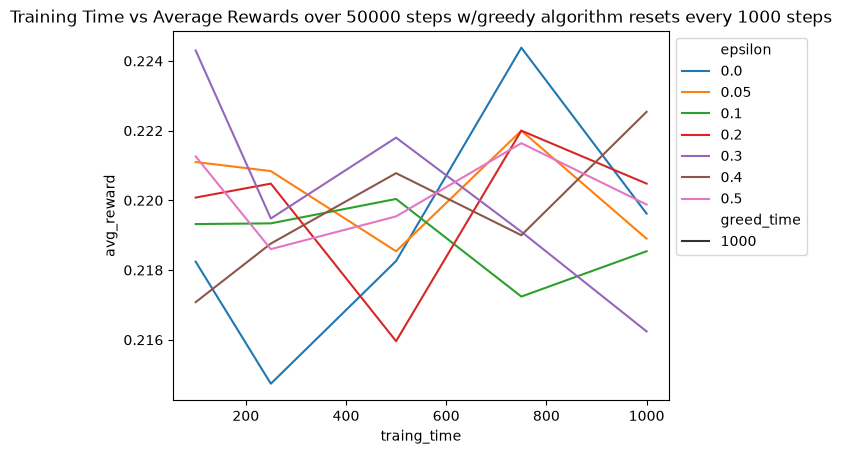

In [118]:
ax = sns.lineplot(data=dt[dt['greed_time']==1000], x='traing_time', y='avg_reward', hue='epsilon', style='greed_time')
sns.move_legend(ax, 'upper left', bbox_to_anchor=(1,1))
ax.set_title('Training Time vs Average Rewards over 50000 steps w/greedy algorithm resets every 1000 steps')
plt.savefig(fname=os.path.join('plots', f"greed_1000.png"), format='png', bbox_inches='tight')

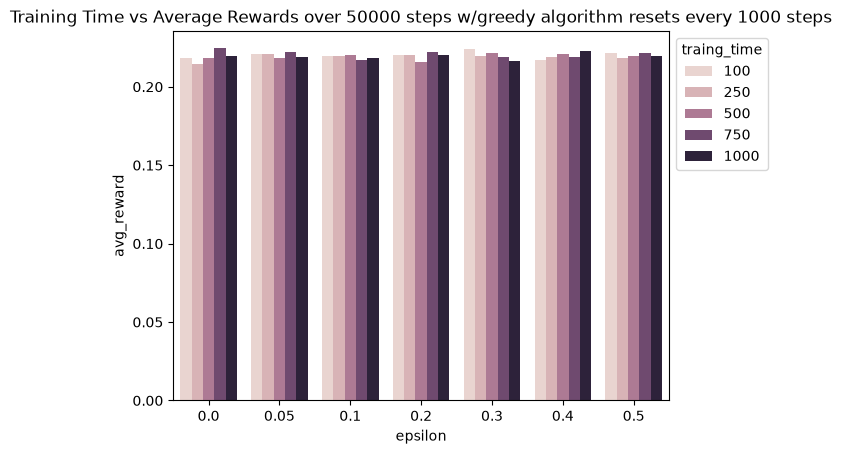

In [139]:
ax = sns.barplot(data=dt[dt['greed_time']==1000], hue='traing_time', y='avg_reward', x='epsilon', )
sns.move_legend(ax, 'upper left', bbox_to_anchor=(1,1))
ax.set_title('Training Time vs Average Rewards over 50000 steps w/greedy algorithm resets every 1000 steps')
plt.savefig(os.path.join('plots',f"greed_bar_1000.png"), format='png', bbox_inches='tight')

In [127]:
class BrokenAgent:
    def __init__(self, b, T, eps, env_config):
        self.b = b # num turns while greedy before refit
        self.T = T # number of training turns
        self.eps = eps # float {0,1} that dictates greed prob
        self.env = Contextual_Bandit_generator(env_config)

    def score(self, a, r):
        qt = self.acts[a][0] # Qt-1
        nt = self.acts[a][1]+1 # Nt(a)
        Qt = qt-((r-qt)/nt)
        # update dict
        self.acts[a][0] = Qt
        self.acts[a][1] = nt

    def greed(self): # finds the 'best' action to take
            actions = self.env.state['article']
            rewards = self.env.state['reward']
            df = pd.DataFrame(data={
                 'action':actions,
                 'reward':rewards
            })
            prob_dict = {'a':[], 'p':[]}
            for a in df['action'].unique():
                 r_sum = df.loc[df['action'] == a]['reward'].sum()
                 prob = r_sum/df.shape[0]
                 prob_dict['a'].append(a)
                 prob_dict['p'].append(prob)
            dt = pd.DataFrame(data=prob_dict)          
            if not dt['p'].ge(self.eps).empty:
                 choice = dt['p'].idxmax()
            else:
                #  choice = dt.loc[dt['p']>=self.eps].idxmin()
                choice = 0
            return choice

    def save_df(self):
        data = {
            'steps':[i for i in range(1,len(self.env.state['article'])+1)],
            'articles':self.env.state['article'],
            'rewards':self.env.state['reward']
        }
        print(len(data['steps']))
        df = pd.DataFrame(data=data)
        fname = f"MAB_T{self.T}_b{self.b}_eps{self.eps}.csv"
        df.to_csv(os.path.join('results', fname), index=False)
                          
    
    def run(self):
        for idx in tqdm(range(50000)): 
            if idx <=self.T: # training 
                self.env.step()
                action = np.random.choice(5) 
                self.env.reward(action)
                greedy_action = self.greed()
            else:
                self.env.step()
                self.env.reward(greedy_action)
            if (idx % self.b == 0) and idx >self.T: # every b steps retrain
                 greedy_action = self.greed()
        return np.mean(self.env.state['reward'])
        
        


In [128]:
training_times = [100, 250, 500, 750, 1000]
greed_time = [100, 1000]
epsilons = [0, 0.05, 0.1, 0.2,0.3,0.4,0.5]

data = {
    'traing_time':[],
    'greed_time':[],
    'epsilon':[],
    'avg_reward':[]
}

for tt in training_times:
    for gt in greed_time:
        for ee in epsilons:
            print(f"T:{tt} b:{gt} Epsilon:{ee}")
            agent = BrokenAgent(gt, tt, ee, env_config)
            mean = agent.run()
            # agent.save_df()
            data['traing_time'].append(tt)
            data['greed_time'].append(gt)
            data['epsilon'].append(ee)
            data['avg_reward'].append(mean)

dy = pd.DataFrame(data=data)

T:100 b:100 Epsilon:0


100%|██████████| 50000/50000 [00:02<00:00, 17202.80it/s]


T:100 b:100 Epsilon:0.05


100%|██████████| 50000/50000 [00:02<00:00, 17566.51it/s]


T:100 b:100 Epsilon:0.1


...

100%|██████████| 50000/50000 [00:03<00:00, 16221.82it/s]


T:1000 b:1000 Epsilon:0.4


100%|██████████| 50000/50000 [00:03<00:00, 16289.48it/s]


T:1000 b:1000 Epsilon:0.5


100%|██████████| 50000/50000 [00:03<00:00, 16248.67it/s]


In [129]:
dy['epsilon'] = dy['epsilon'].astype('category')

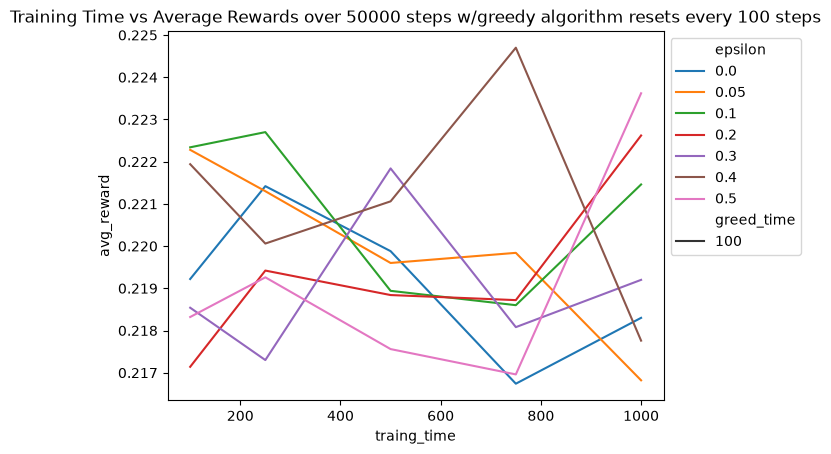

In [130]:
ax = sns.lineplot(data=dy.loc[dy['greed_time']==100], x='traing_time', y='avg_reward', hue='epsilon', style='greed_time')
sns.move_legend(ax, 'upper left', bbox_to_anchor=(1,1))
ax.set_title('Training Time vs Average Rewards over 50000 steps w/greedy algorithm resets every 100 steps')
plt.savefig(fname=os.path.join('plots', f"broke_greed_100.png"), format='png', bbox_inches='tight')

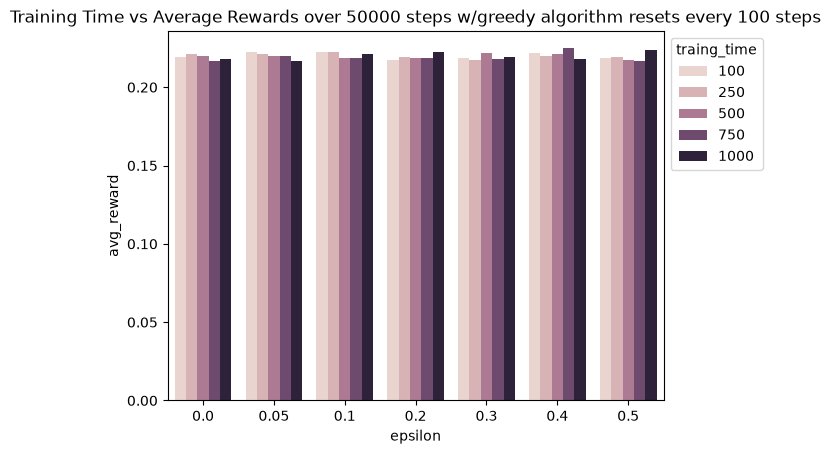

In [140]:
ax = sns.barplot(data=dy[dy['greed_time']==100], hue='traing_time', y='avg_reward', x='epsilon', )
sns.move_legend(ax, 'upper left', bbox_to_anchor=(1,1))
ax.set_title('Training Time vs Average Rewards over 50000 steps w/greedy algorithm resets every 100 steps')
plt.savefig(os.path.join('plots',f"broke_greed_bar_100.png"), format='png', bbox_inches='tight')

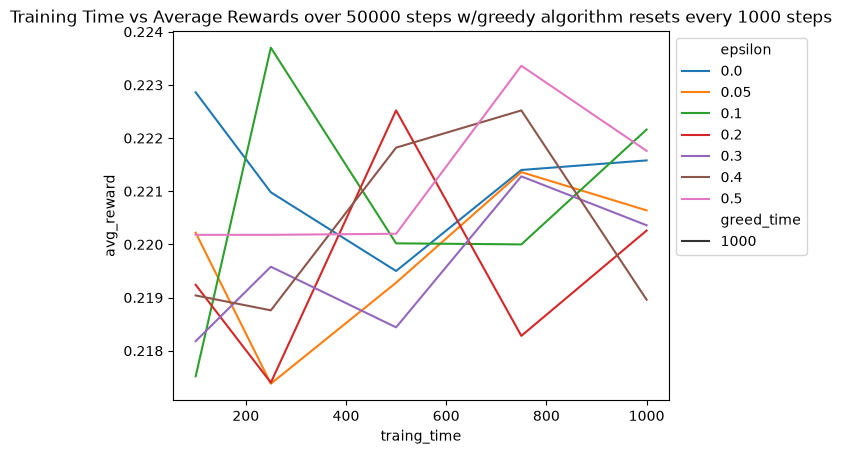

In [131]:
ax = sns.lineplot(data=dy[dy['greed_time']==1000], x='traing_time', y='avg_reward', hue='epsilon', style='greed_time')
sns.move_legend(ax, 'upper left', bbox_to_anchor=(1,1))
ax.set_title('Training Time vs Average Rewards over 50000 steps w/greedy algorithm resets every 1000 steps')
plt.savefig(fname=os.path.join('plots', f"broke_greed_1000.png"), format='png', bbox_inches='tight')

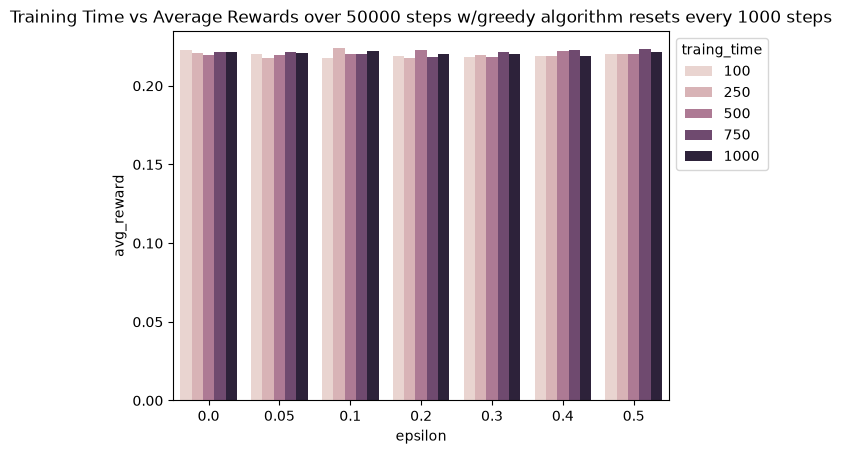

In [141]:
ax = sns.barplot(data=dy[dy['greed_time']==1000], hue='traing_time', y='avg_reward', x='epsilon', )
sns.move_legend(ax, 'upper left', bbox_to_anchor=(1,1))
ax.set_title('Training Time vs Average Rewards over 50000 steps w/greedy algorithm resets every 1000 steps')
plt.savefig(os.path.join('plots',f"broke_greed_bar_1000.png"), format='png', bbox_inches='tight')

In [147]:
class BrokenAgent2:
    def __init__(self, b, T, eps, env_config):
        self.b = b # num turns while greedy before refit
        self.T = T # number of training turns
        self.eps = eps # float {0,1} that dictates greed prob
        self.env = Contextual_Bandit_generator(env_config)
        self.previous = 0

    def greed(self): # finds the 'best' action to take
            actions = self.env.state['article']
            rewards = self.env.state['reward']
            df = pd.DataFrame(data={
                 'action':actions,
                 'reward':rewards
            })
            prob_dict = {'a':[], 'p':[]}
            for a in df['action'].unique():
                 r_sum = df.loc[df['action'] == a]['reward'].sum()
                 prob = r_sum/df.shape[0]
                 prob_dict['a'].append(a)
                 prob_dict['p'].append(prob)
            dt = pd.DataFrame(data=prob_dict)          
            if not dt['p'].ge(self.eps).empty:
                 choice = dt['p'].idxmax()
                 self.previous = choice
            else:
                #  choice = dt.loc[dt['p']>=self.eps].idxmin()
                choice = self.previous
            return choice

    def save_df(self):
        data = {
            'steps':[i for i in range(1,len(self.env.state['article'])+1)],
            'articles':self.env.state['article'],
            'rewards':self.env.state['reward']
        }
        print(len(data['steps']))
        df = pd.DataFrame(data=data)
        fname = f"MAB_T{self.T}_b{self.b}_eps{self.eps}.csv"
        df.to_csv(os.path.join('results', fname), index=False)
                          
    
    def run(self):
        for idx in tqdm(range(50000)): 
            if idx <=self.T: # training 
                self.env.step()
                action = np.random.choice(5) 
                self.env.reward(action)
                greedy_action = self.greed()
            else:
                self.env.step()
                self.env.reward(greedy_action)
            if (idx % self.b == 0) and idx >self.T: # every b steps retrain
                 greedy_action = self.greed()
        return np.mean(self.env.state['reward'])
 

In [148]:
training_times = [100, 250, 500, 750, 1000]
greed_time = [100, ]
epsilons = [0, 0.05, 0.1, 0.2,0.3,0.4,0.5]

data = {
    'traing_time':[],
    'greed_time':[],
    'epsilon':[],
    'avg_reward':[]
}

for tt in training_times:
    for gt in greed_time:
        for ee in epsilons:
            print(f"T:{tt} b:{gt} Epsilon:{ee}")
            agent = BrokenAgent2(gt, tt, ee, env_config)
            mean = agent.run()
            # agent.save_df()
            data['traing_time'].append(tt)
            data['greed_time'].append(gt)
            data['epsilon'].append(ee)
            data['avg_reward'].append(mean)

dm = pd.DataFrame(data=data)

T:100 b:100 Epsilon:0


100%|██████████| 50000/50000 [00:03<00:00, 16038.56it/s]


T:100 b:100 Epsilon:0.05


100%|██████████| 50000/50000 [00:02<00:00, 16812.06it/s]


T:100 b:100 Epsilon:0.1


...

100%|██████████| 50000/50000 [00:03<00:00, 14030.83it/s]


T:1000 b:100 Epsilon:0.4


100%|██████████| 50000/50000 [00:03<00:00, 14016.78it/s]


T:1000 b:100 Epsilon:0.5


100%|██████████| 50000/50000 [00:03<00:00, 13960.59it/s]


In [150]:
dm['epsilon'] = dm['epsilon'].astype('category')

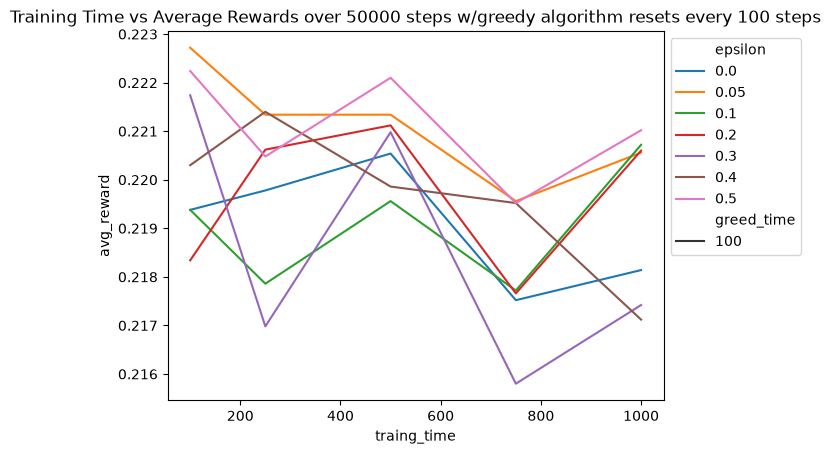

In [151]:
ax = sns.lineplot(data=dm.loc[dm['greed_time']==100], x='traing_time', y='avg_reward', hue='epsilon', style='greed_time')
sns.move_legend(ax, 'upper left', bbox_to_anchor=(1,1))
ax.set_title('Training Time vs Average Rewards over 50000 steps w/greedy algorithm resets every 100 steps')
plt.savefig(fname=os.path.join('plots', f"broke_fixed_greed_100.png"), format='png', bbox_inches='tight')